# Nitrogen on copper: an ASE introduction

This notebook follows the [official ASE introduction](https://docs.ase-lib.org/examples_generated/01-gettingstarted/00-n2cu.html). It uses a small adsorption problem to connect the main pieces of an ASE workflow: constructing atomic systems, attaching a calculator, relaxing a structure, saving and visualizing results, and running molecular dynamics.

The target quantity is the adsorption energy of an $N_2$ molecule on a Cu(111) slab:

$$
E_{ads} = E_{slab} + E_{N_2} - E_{slab+N_2}
$$

All three energies must be evaluated with the same calculator. With this sign convention, a positive $E_{ads}$ means that the combined, relaxed system is lower in energy than the two isolated reference systems. Energies are reported in electronvolts (eV), distances in ångström (Å), and forces in eV/Å.

The first code cell runs the complete calculation. The remaining sections rebuild the workflow one step at a time.

In [1]:
from ase import Atoms
from ase.build import add_adsorbate, fcc111
from ase.calculators.emt import EMT
from ase.constraints import FixAtoms
from ase.optimize import QuasiNewton

h = 1.85
d = 1.10

slab = fcc111('Cu', size=(4, 4, 2), vacuum=10.0)

slab.calc = EMT()
e_slab = slab.get_potential_energy()

molecule = Atoms('2N', positions=[(0.0, 0.0, 0.0), (0.0, 0.0, d)])
molecule.calc = EMT()
e_N2 = molecule.get_potential_energy()

add_adsorbate(slab, molecule, h, 'ontop')
constraint = FixAtoms(mask=[a.symbol != 'N' for a in slab])
slab.set_constraint(constraint)
dyn = QuasiNewton(slab, trajectory='../files/tutorial_01/N2Cu.traj')
dyn.run(fmax=0.05)

print('Adsorption energy:', e_slab + e_N2 - slab.get_potential_energy())

                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 20:39:35       11.689927       1.0797
BFGSLineSearch:    1[  2] 20:39:35       11.670814       0.4090
BFGSLineSearch:    2[  4] 20:39:35       11.625880       0.0409
Adsorption energy: 0.32351942231763964


## Atoms: molecule and surface

An `Atoms` object stores chemical symbols, Cartesian positions, the simulation cell, periodic-boundary settings, and optional calculation data.

The molecule contains two nitrogen atoms aligned with the $z$ axis and separated by $d = 1.10$ Å. Because no cell or periodic boundaries are supplied, it is treated as an isolated molecule.

`fcc111()` constructs a Cu(111) surface. Here, `size=(4, 4, 2)` makes a four-by-four surface repeat with two atomic layers, while `vacuum=10.0` leaves 10 Å of empty space on each side of the slab along the surface normal. The slab is periodic in the two in-plane directions and nonperiodic along $z$. The compact object representations below confirm an $N_2$ molecule and a 32-atom Cu slab.

In [2]:
d = 1.10
molecule = Atoms('2N', positions=[(0.0, 0.0, 0.0), (0.0, 0.0, d)])

In [3]:
molecule

Atoms(symbols='N2', pbc=False)

In [4]:
from ase.build import fcc111

slab = fcc111('Cu', size=(4, 4, 2), vacuum=10.0)

In [5]:
slab

Atoms(symbols='Cu32', pbc=[True, True, False], cell=[[10.210621920333747, 0.0, 0.0], [5.105310960166873, 8.842657971447272, 0.0], [0.0, 0.0, 22.08423447177455]], tags=...)

## Adding a calculator

Geometry alone does not define energies or forces. ASE delegates those properties to a calculator attached through the `calc` attribute.

This tutorial uses the effective-medium theory (`EMT`) calculator because it is fast and has no external executable. It is well suited to learning the ASE workflow, but the resulting adsorption energy should be treated as a model result rather than a high-accuracy prediction.

Calling `get_potential_energy()` triggers the calculator and returns the total potential energy in eV. The isolated slab and molecule energies are saved now because they form the reference side of the adsorption-energy expression.

In [6]:
from ase.calculators.emt import EMT

slab.calc = EMT()
molecule.calc = EMT()

In [7]:
e_slab = slab.get_potential_energy()
e_N2 = molecule.get_potential_energy()

In [8]:
print(e_slab, e_N2)

11.509056283569901 0.440343573035614


## Structure relaxation

The molecule is placed at an on-top adsorption site with its lower nitrogen atom initially $h = 1.85$ Å above the surface atom. This is only a starting geometry; relaxation moves the adsorbate toward a nearby local minimum.

The `FixAtoms` mask is `True` for every non-nitrogen atom, so all Cu atoms remain fixed and only the two N atoms can move. This makes the example inexpensive, but it excludes relaxation of the copper surface.

`QuasiNewton` minimizes the potential energy using the calculated forces. The run stops when the largest remaining force on the movable atoms falls below $0.05$ eV/Å. Each optimization image is written to `N2Cu.traj`, allowing the relaxation path to be inspected later.

In [9]:
h = 1.85
add_adsorbate(slab, molecule, h, 'ontop')

In [10]:
from ase.constraints import FixAtoms

constraint = FixAtoms(mask=[a.symbol != 'N' for a in slab])
slab.set_constraint(constraint)

In [11]:
from ase.optimize import QuasiNewton

dyn = QuasiNewton(slab, trajectory='../files/tutorial_01/N2Cu.traj')
dyn.run(fmax=0.05)

                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 20:39:35       11.689927       1.0797
BFGSLineSearch:    1[  2] 20:39:35       11.670814       0.4090
BFGSLineSearch:    2[  4] 20:39:35       11.625880       0.0409


np.True_

### Interpreting the adsorption energy

The complete calculation reports $E_{ads} ≈ 0.324$ eV. Under the sign convention defined above, the positive value indicates favorable adsorption relative to this calculation's isolated slab and molecule. The number is specific to EMT, the chosen cell, the on-top starting site, and the constraint that keeps every Cu atom fixed.

## Input and output

`ase.io.write()` selects a format from the filename and stores the relaxed structure in `../files/tutorial_01/slab.xyz`. `ase.io.read()` reconstructs an `Atoms` object from that file. Relative paths are resolved from the notebook kernel's working directory.

The XYZ file is useful for exchanging a single structure. The ASE trajectory created during relaxation serves a different purpose: it can retain the sequence of optimization images for later analysis or animation.

In [12]:
from ase.io import write

write('../files/tutorial_01/slab.xyz', slab)

/Users/liangze/Desktop/Experiences/ase_learning/.venv/lib/python3.14/site-packages/ase/io/extxyz.py:320: UserWarning: Skipping unhashable information adsorbate_info
  warnings.warn('Skipping unhashable information '


In [13]:
from ase.io import read

slab_from_file = read('../files/tutorial_01/slab.xyz')

In [14]:
slab_from_file

Atoms(symbols='Cu32N2', pbc=[True, True, False], cell=[[10.210621920333747, 0.0, 0.0], [5.105310960166873, 8.842657971447272, 0.0], [0.0, 0.0, 22.08423447177455]], tags=..., constraint=FixAtoms(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]), calculator=SinglePointCalculator(...))

## Visualization

Visualization checks whether the model was assembled and relaxed as intended; it does not change the atomic structure. `viewer='x3d'` creates an interactive three-dimensional view inside a compatible notebook, while `plot_atoms()` draws a static Matplotlib projection.

The second plot deliberately uses `slab_from_file`, providing a quick visual check that the written structure can be read back successfully.

In [15]:
from ase.visualize import view
view(slab, viewer='x3d')

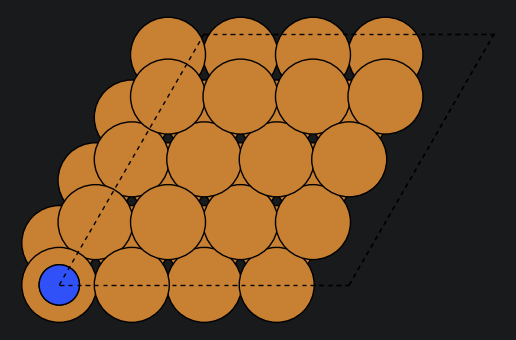

In [16]:
import matplotlib.pyplot as plt

from ase.visualize.plot import plot_atoms

fig, ax = plt.subplots()
plot_atoms(slab_from_file, ax)
ax.set_axis_off()

## Molecular dynamics

`VelocityVerlet` integrates the classical equations of motion for the isolated $N_2$ molecule with a time step of 1 fs. No thermostat or velocity initializer is used, so the atoms start with zero velocity and begin moving under the EMT forces.

At each report, the code prints the potential energy, kinetic energy, and their sum:

$$
E_{tot} = E_{pot} + E_{kin}
$$

For this unthermostatted trajectory, $E_{tot}$ should remain approximately constant; small variations arise from the finite integration time step. Each loop iteration advances 20 steps, so the ten blocks propagate 200 fs in total. The printed rows correspond to 0, 20, ..., 180 fs because each energy report occurs before its next 20-step block.

In [17]:
from ase import units
from ase.md.verlet import VelocityVerlet

dyn = VelocityVerlet(molecule, timestep=1.0 * units.fs)
for i in range(10):
    pot = molecule.get_potential_energy()
    kin = molecule.get_kinetic_energy()
    print('%2d: %.5f eV, %.5f eV, %.5f eV' % (i, pot + kin, pot, kin))
    dyn.run(steps=20)

 0: 0.44034 eV, 0.44034 eV, 0.00000 eV
 1: 0.43816 eV, 0.26289 eV, 0.17527 eV
 2: 0.44058 eV, 0.43142 eV, 0.00916 eV
 3: 0.43874 eV, 0.29292 eV, 0.14582 eV
 4: 0.44015 eV, 0.41839 eV, 0.02176 eV
 5: 0.43831 eV, 0.28902 eV, 0.14929 eV
 6: 0.43947 eV, 0.36902 eV, 0.07045 eV
 7: 0.43951 eV, 0.35507 eV, 0.08444 eV
 8: 0.43959 eV, 0.36221 eV, 0.07738 eV
 9: 0.43933 eV, 0.36044 eV, 0.07889 eV


## Takeaways and possible extensions

This example demonstrates the central ASE pattern: an `Atoms` object describes a system, a calculator supplies energies and forces, and ASE tools operate on that pair. Constraints and optimizers prepare a relaxed geometry; I/O and visualization make the result reusable; and an integrator propagates the atoms in time.

Useful follow-up experiments include comparing on-top, bridge, and hollow adsorption sites; allowing one Cu layer to relax; checking sensitivity to the slab size; and initializing molecular velocities before monitoring temperature. When comparing adsorption energies, keep the calculator and numerical settings consistent across every reference system.